In [6]:
from pystac.client import Client
from odc.stac import load

# Connect securely to the Digital Earth Pacific STAC instance API
catalog_url = "https://stac.digitalearthpacific.org"
client = Client.open(catalog_url)

# Define the precise spatial bounding box (BBOX) for the Dawasamu Catchment (Fiji)
# Format: (Min Longitude, Min Latitude, Max Longitude, Max Latitude)
dawasamu_bbox = (178.45, -17.70, 178.60, -17.55) 

# Search for relevant satellite imagery collections
search = client.search(
    collections=["dep_s2_mangroves"],  # Swap out with target LULC collections as needed
    bbox=dawasamu_bbox
)

items = search.item_collection()
print(f"Found {len(items)} spatial observation assets matching Dawasamu coordinates!")

Found 18 spatial observation assets matching Dawasamu coordinates!


In [5]:
items

In [10]:
# 4. Load the true-color bands (Red, Green, Blue) into an xarray Dataset
# We reproject directly into Fiji's UTM Zone 60S matching your InVEST CRS!
ds = load(
    items,
    bbox=dawasamu_bbox,
    crs="EPSG:32760",  # WGS 84 / UTM Zone 60S
    resolution=10,  # High-resolution 10-meter pixels
    chunks={},  # Lazy loading via dask for speed optimization
)

# =====================================================================
# THE MEDIAN REDUCTION STEP
# =====================================================================
# 5. Calculate the median across the time dimension to mask out clouds
print("Calculating cloud-free median mosaic composite matrix...")
median_image = ds.median(dim="time").compute()
median_image

Calculating cloud-free median mosaic composite matrix...


<xarray.Dataset> Size: 22MB
Dimensions:      (y: 1674, x: 1606)
Coordinates:
  * y            (y) float64 13kB 8.059e+06 8.059e+06 ... 8.042e+06 8.042e+06
  * x            (x) float64 13kB 6.538e+05 6.538e+05 ... 6.698e+05 6.698e+05
    spatial_ref  int32 4B 32760
Data variables:
    mangroves    (y, x) float64 22MB 255.0 255.0 255.0 ... 255.0 255.0 255.0

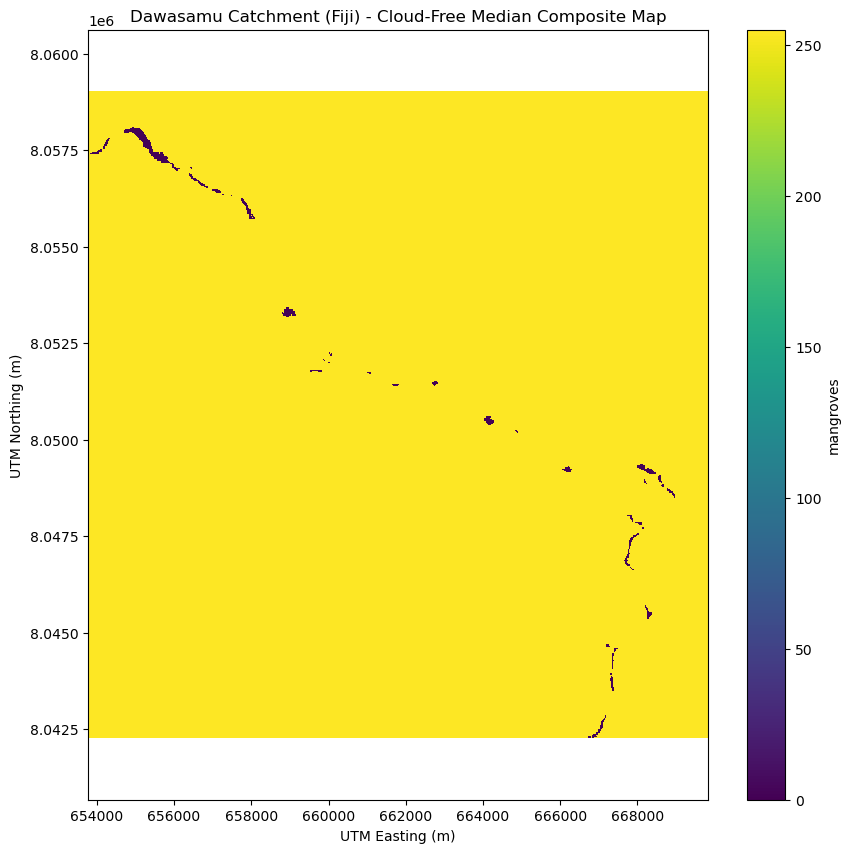

In [13]:

# # 6. Normalize the 16-bit Sentinel-2 integer values (0-10000) to 0-1 for plotting
# rgb_image = (
#     median_image.to_array(dim="band") / 3000.0
# )
# rgb_image = rgb_image.clip(0, 1)  # Clip outliers to keep the image bright

# =====================================================================
# PLOT THE MAP OUTPUT
# =====================================================================
import matplotlib.pyplot as plt

# 7. Render the imagery using Matplotlib
plt.figure(figsize=(10, 10))
# Transpose dimensions from (band, y, x) to (y, x, band) as required by imshow
median_image.mangroves.transpose("y", "x").plot.imshow()

plt.title("Dawasamu Catchment (Fiji) - Cloud-Free Median Composite Map")
plt.xlabel("UTM Easting (m)")
plt.ylabel("UTM Northing (m)")
plt.axis("equal")
plt.show()